# Scénario Anomaly Detection — Equipment Monitoring (One-Class CL)

| Champ | Valeur |
|-------|--------|
| **Scénario** | One-class : entraîner sur `faulty=0` uniquement, évaluer sur `faulty=0` + `faulty=1` |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons, 3 domaines |
| **Tâches CL** | Pump → Turbine → Compressor (domain-incremental) |
| **Modèles** | Mahalanobis, KMeans, HDC (one-class), TinyOL AE |
| **Expériences** | exp_086 (HDC), exp_087 (TinyOL AE), exp_088 (KMeans), exp_089 (Mahalanobis) |
| **Metric principale** | AUROC (Area Under ROC Curve) |

> **Pourquoi ce scénario ?**  
> En maintenance industrielle réelle, les pannes sont rares et souvent inconnues à l'entraînement.
> Ce scénario simule un déploiement réaliste : le modèle apprend uniquement depuis des données
> de fonctionnement normal, et doit détecter les anomalies en production.

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_anomaly_detection/notebook_anomaly_detection.ipynb \
    --output /tmp/anomaly_detection_executed.ipynb
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_anomaly_detection":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data.monitoring_dataset import get_cl_dataloaders_anomaly_detection
from src.evaluation.anomaly_metrics import compute_anomaly_metrics, compute_cl_anomaly_metrics, save_anomaly_metrics
from src.evaluation.plots import (
    plot_anomaly_score_distributions,
    plot_roc_curves_per_task,
    save_figure,
)
from src.models.hdc.hdc_classifier import HDCClassifier
from src.models.tinyol.tinyol_anomaly_detector import TinyOLAnomalyDetector
from src.models.unsupervised.kmeans_detector import KMeansDetector
from src.models.unsupervised.mahalanobis_detector import MahalanobisDetector
from src.training.scenarios import run_anomaly_detection_scenario
from src.utils.config_loader import load_config

# --- Chemins ---
CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer_anomaly.yaml"
FIGURES_DIR     = REPO_ROOT / "notebooks/figures/cl_evaluation/anomaly_detection/monitoring"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES    = ["Pump", "Turbine", "Compressor"]
DATA_AVAILABLE = CSV_PATH.exists()

print(f"REPO_ROOT      : {REPO_ROOT}")
print(f"FIGURES_DIR    : {FIGURES_DIR}")
print(f"CSV disponible : {DATA_AVAILABLE}")
print(f"Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

REPO_ROOT      : /home/leonard/Documents/ENAC/cl-embedded
FIGURES_DIR    : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/anomaly_detection/monitoring
CSV disponible : True
Date exécution : 2026-04-27 10:16


In [2]:
# Section 2 — Chargement des données et vérification du split
if not DATA_AVAILABLE:
    raise RuntimeError(f"CSV introuvable : {CSV_PATH}")

tasks = get_cl_dataloaders_anomaly_detection(CSV_PATH, NORMALIZER_PATH)

print("Vérification du split anomaly detection :")
print(f"{'Tâche':<12} {'n_train (normal)':<18} {'n_test_normal':<15} {'n_test_faulty':<15} {'% faulty test'}")
print("-" * 75)
for t in tasks:
    pct_faulty = t['n_test_faulty'] / t['n_test'] * 100
    print(f"{t['domain']:<12} {t['n_train']:<18} {t['n_test_normal']:<15} {t['n_test_faulty']:<15} {pct_faulty:.1f}%")

# Double vérification : train ne contient que des normaux
for t in tasks:
    y_train = np.concatenate([b[1].numpy().flatten() for b in t['train_loader']])
    assert y_train.sum() == 0, f"Train contient des faulty pour {t['domain']}!"
print("\nAssertion OK : train_loader ne contient que faulty=0 pour toutes les tâches")

✅ Seed fixé à 42
Vérification du split anomaly detection :
Tâche        n_train (normal)   n_test_normal   n_test_faulty   % faulty test
---------------------------------------------------------------------------
Pump         1825               457             252             35.5%
Turbine      1845               462             258             35.8%
Compressor   1852               464             257             35.6%

Assertion OK : train_loader ne contient que faulty=0 pour toutes les tâches


In [3]:
# Section 3 — Exécution des 4 modèles

# --- Mahalanobis ---
print("=" * 60)
print("Mahalanobis")
print("=" * 60)
cfg_maha = load_config(str(REPO_ROOT / "configs/unsupervised_anomaly_detection_config.yaml"))["mahalanobis"]
model_maha = MahalanobisDetector(cfg_maha)
auroc_maha, scores_maha = run_anomaly_detection_scenario(model_maha, tasks, cfg_maha)
cl_maha = compute_cl_anomaly_metrics(auroc_maha)
print(f"\nMahalanobis — avg_auroc={cl_maha['avg_auroc']:.4f}, forgetting={cl_maha['auroc_forgetting']:.4f}")

Mahalanobis
  [Mahalanobis] Tâche 0 — μ shape=(4,), Σ⁻¹ shape=(4, 4), RAM estimée=80 B
  [Mahalanobis] Seuil calculé sur Task 0 : 3.0937 (percentile 95)
  [AD] après tâche 1/3, eval tâche 1 (Pump        ) — AUROC=0.9883 F1=0.9459
  [Mahalanobis] Tâche 1 — μ shape=(4,), Σ⁻¹ shape=(4, 4), RAM estimée=80 B
  [AD] après tâche 2/3, eval tâche 1 (Pump        ) — AUROC=0.9880 F1=0.9514
  [AD] après tâche 2/3, eval tâche 2 (Turbine     ) — AUROC=0.9800 F1=0.9377
  [Mahalanobis] Tâche 2 — μ shape=(4,), Σ⁻¹ shape=(4, 4), RAM estimée=80 B
  [AD] après tâche 3/3, eval tâche 1 (Pump        ) — AUROC=0.9882 F1=0.9430
  [AD] après tâche 3/3, eval tâche 2 (Turbine     ) — AUROC=0.9802 F1=0.9375
  [AD] après tâche 3/3, eval tâche 3 (Compressor  ) — AUROC=0.9945 F1=0.9644

Mahalanobis — avg_auroc=0.9877, forgetting=-0.0001


In [4]:
# --- KMeans ---
print("=" * 60)
print("KMeans")
print("=" * 60)
cfg_unsup = load_config(str(REPO_ROOT / "configs/unsupervised_anomaly_detection_config.yaml"))
cfg_km = cfg_unsup["kmeans"]
model_km = KMeansDetector(cfg_km)
auroc_km, scores_km = run_anomaly_detection_scenario(model_km, tasks, cfg_km)
cl_km = compute_cl_anomaly_metrics(auroc_km)
print(f"\nKMeans — avg_auroc={cl_km['avg_auroc']:.4f}, forgetting={cl_km['auroc_forgetting']:.4f}")

KMeans
  [KMeans] Tâche 0 — K sélectionné : 8 (méthode=silhouette)
  [KMeans] Seuil calculé sur Task 0 : 2.1867 (percentile 95)
  [AD] après tâche 1/3, eval tâche 1 (Pump        ) — AUROC=0.9878 F1=0.9310
  [KMeans] Tâche 1 — K sélectionné : 5 (méthode=silhouette)
  [AD] après tâche 2/3, eval tâche 1 (Pump        ) — AUROC=0.9860 F1=0.9346
  [AD] après tâche 2/3, eval tâche 2 (Turbine     ) — AUROC=0.9800 F1=0.9349
  [KMeans] Tâche 2 — K sélectionné : 7 (méthode=silhouette)
  [AD] après tâche 3/3, eval tâche 1 (Pump        ) — AUROC=0.9860 F1=0.9360
  [AD] après tâche 3/3, eval tâche 2 (Turbine     ) — AUROC=0.9757 F1=0.9375
  [AD] après tâche 3/3, eval tâche 3 (Compressor  ) — AUROC=0.9908 F1=0.9665

KMeans — avg_auroc=0.9841, forgetting=0.0031


In [5]:
# --- HDC one-class ---
print("=" * 60)
print("HDC (one-class mode)")
print("=" * 60)
cfg_hdc = load_config(str(REPO_ROOT / "configs/hdc_anomaly_detection_config.yaml"))
model_hdc = HDCClassifier(cfg_hdc)
assert model_hdc.one_class_mode, "HDC doit être en one_class_mode!"
auroc_hdc, scores_hdc = run_anomaly_detection_scenario(model_hdc, tasks, cfg_hdc)
cl_hdc = compute_cl_anomaly_metrics(auroc_hdc)
print(f"\nHDC one-class — avg_auroc={cl_hdc['avg_auroc']:.4f}, forgetting={cl_hdc['auroc_forgetting']:.4f}")

HDC (one-class mode)
  [HDC one-class] Seuil calculé sur Task 1 : 0.6191 (percentile 95)
  [AD] après tâche 1/3, eval tâche 1 (Pump        ) — AUROC=0.9459 F1=0.8410
  [AD] après tâche 2/3, eval tâche 1 (Pump        ) — AUROC=0.9460 F1=0.8443
  [AD] après tâche 2/3, eval tâche 2 (Turbine     ) — AUROC=0.9307 F1=0.8273
  [AD] après tâche 3/3, eval tâche 1 (Pump        ) — AUROC=0.9460 F1=0.8443
  [AD] après tâche 3/3, eval tâche 2 (Turbine     ) — AUROC=0.9307 F1=0.8273
  [AD] après tâche 3/3, eval tâche 3 (Compressor  ) — AUROC=0.9586 F1=0.8621

HDC one-class — avg_auroc=0.9451, forgetting=-0.0000


In [6]:
# --- TinyOL Autoencoder ---
print("=" * 60)
print("TinyOL Autoencoder")
print("=" * 60)
cfg_tinyol = load_config(str(REPO_ROOT / "configs/tinyol_anomaly_detection_config.yaml"))
# checkpoint_path contient un placeholder — désactiver la sauvegarde pour ce notebook
cfg_tinyol["backbone"]["checkpoint_path"] = None
model_tinyol = TinyOLAnomalyDetector(cfg_tinyol)
auroc_tinyol, scores_tinyol = run_anomaly_detection_scenario(model_tinyol, tasks, cfg_tinyol)
cl_tinyol = compute_cl_anomaly_metrics(auroc_tinyol)
print(f"\nTinyOL AE — avg_auroc={cl_tinyol['avg_auroc']:.4f}, forgetting={cl_tinyol['auroc_forgetting']:.4f}")

TinyOL Autoencoder


/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  [TinyOL AE] Seuil calculé sur Task 1 : 2.036065 (percentile 95)
  [AD] après tâche 1/3, eval tâche 1 (Pump        ) — AUROC=0.9791 F1=0.9465
  [AD] après tâche 2/3, eval tâche 1 (Pump        ) — AUROC=0.9694 F1=0.9309
  [AD] après tâche 2/3, eval tâche 2 (Turbine     ) — AUROC=0.9686 F1=0.9120
  [AD] après tâche 3/3, eval tâche 1 (Pump        ) — AUROC=0.9733 F1=0.9314
  [AD] après tâche 3/3, eval tâche 2 (Turbine     ) — AUROC=0.9665 F1=0.9069
  [AD] après tâche 3/3, eval tâche 3 (Compressor  ) — AUROC=0.9762 F1=0.9167

TinyOL AE — avg_auroc=0.9720, forgetting=0.0039


In [7]:
# Section 4 — Tableau récapitulatif des métriques CL
results = {
    "Mahalanobis": cl_maha,
    "KMeans":      cl_km,
    "HDC (one-class)": cl_hdc,
    "TinyOL AE":   cl_tinyol,
}

print(f"{'Modèle':<20} {'avg_AUROC':>10} {'AUROC_forgetting':>18} {'AUROC_BWT':>12}")
print("-" * 65)
for name, m in results.items():
    print(f"{name:<20} {m['avg_auroc']:>10.4f} {m['auroc_forgetting']:>18.4f} {m['auroc_bwt']:>12.4f}")

Modèle                avg_AUROC   AUROC_forgetting    AUROC_BWT
-----------------------------------------------------------------
Mahalanobis              0.9877            -0.0001       0.0001
KMeans                   0.9841             0.0031      -0.0031
HDC (one-class)          0.9451            -0.0000       0.0000
TinyOL AE                0.9720             0.0039      -0.0039


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/anomaly_detection/monitoring/auroc_matrices.png


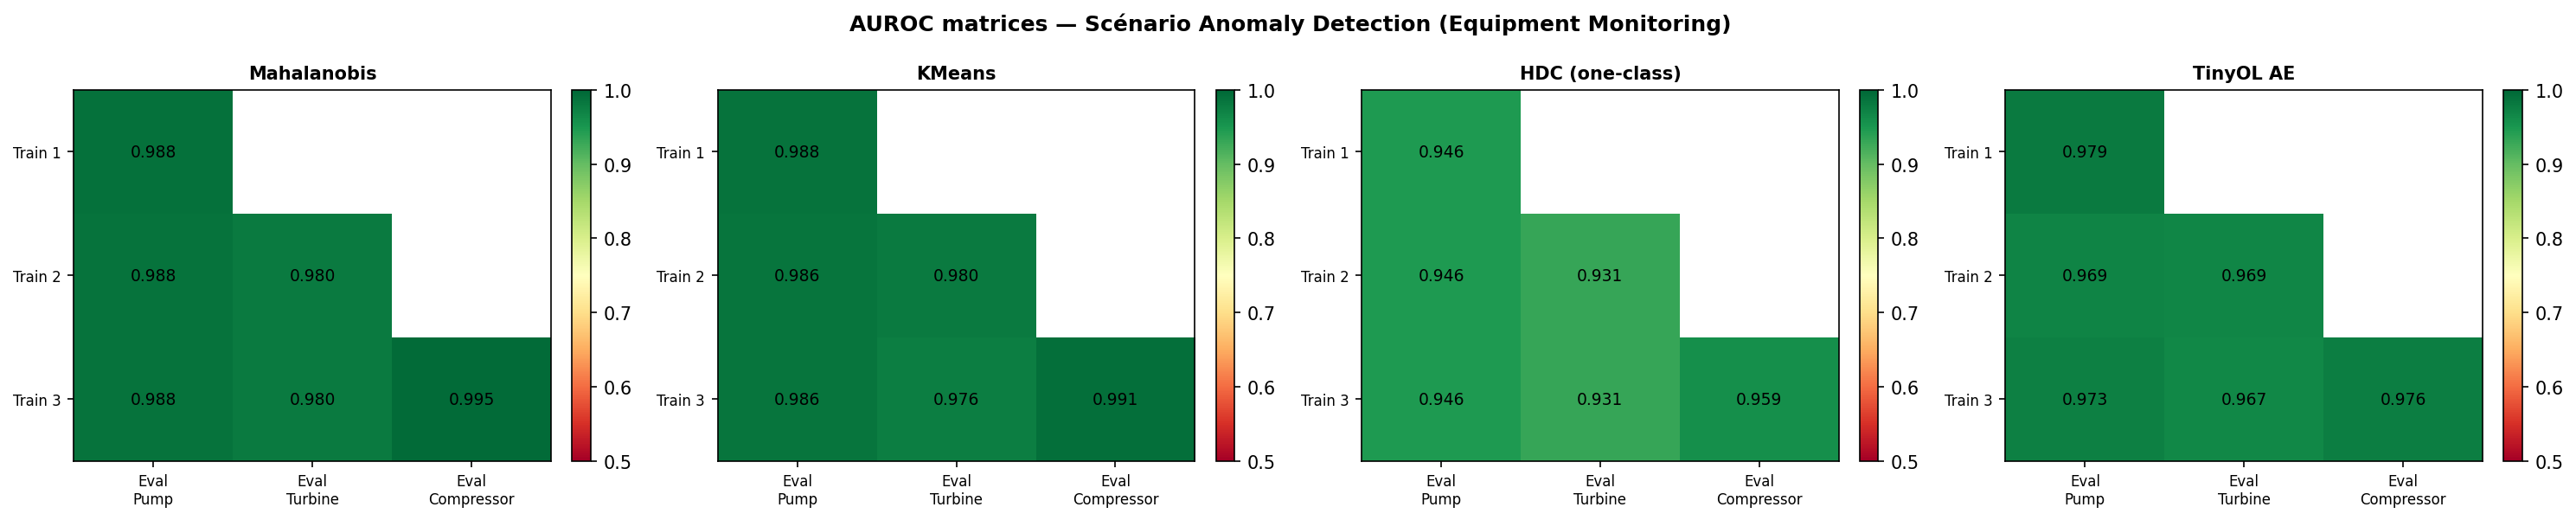

In [8]:
# Section 5 — Matrices AUROC (heatmap) pour chaque modèle
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

model_names  = ["Mahalanobis", "KMeans", "HDC (one-class)", "TinyOL AE"]
auroc_mats   = [auroc_maha, auroc_km, auroc_hdc, auroc_tinyol]

for ax, name, mat in zip(axes, model_names, auroc_mats):
    im = ax.imshow(mat, vmin=0.5, vmax=1.0, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels([f"Eval\n{n}" for n in TASK_NAMES], fontsize=8)
    ax.set_yticklabels([f"Train {i+1}" for i in range(3)], fontsize=8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    for i in range(3):
        for j in range(3):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=9,
                        color="black" if v > 0.65 else "white")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("AUROC matrices — Scénario Anomaly Detection (Equipment Monitoring)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_figure(fig, FIGURES_DIR / "auroc_matrices.png")
display(Image(str(FIGURES_DIR / "auroc_matrices.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/anomaly_detection/monitoring/score_distributions_task0.png


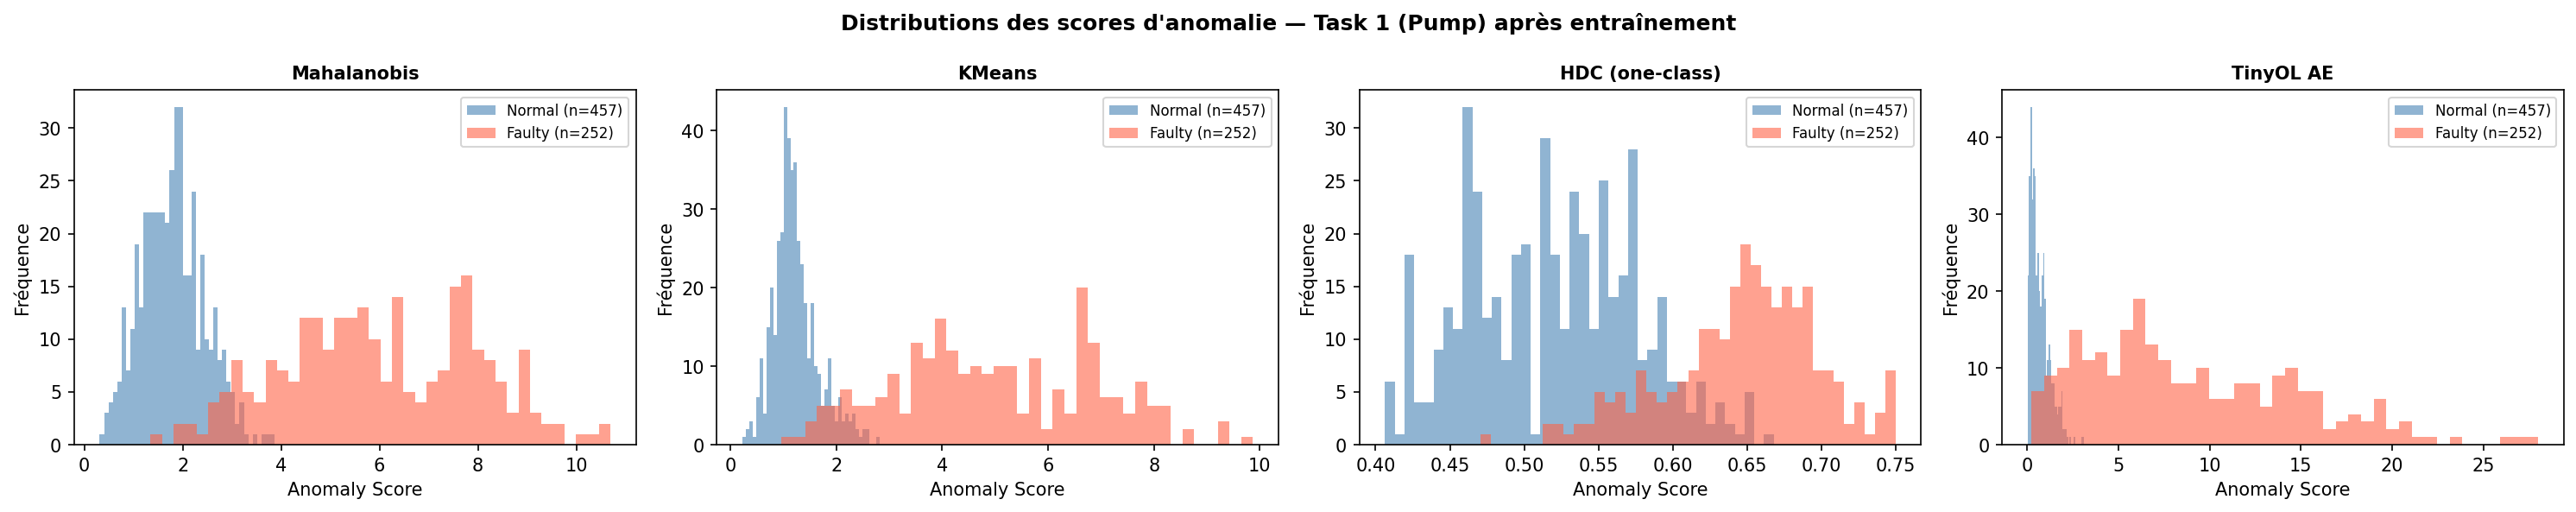

In [9]:
# Section 6 — Distributions des scores d'anomalie (normal vs faulty) — Task 0 post-train
# Utiliser les scores de (i=0, j=0) : après Task 1, évaluer Task 1
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

all_scores = [scores_maha, scores_km, scores_hdc, scores_tinyol]

for ax, name, scores_dict in zip(axes, model_names, all_scores):
    y_true, scores = scores_dict[(0, 0)]
    s_normal = scores[y_true == 0]
    s_faulty = scores[y_true == 1]
    ax.hist(s_normal, bins=40, alpha=0.6, color="steelblue", label=f"Normal (n={len(s_normal)})")
    ax.hist(s_faulty, bins=40, alpha=0.6, color="tomato",    label=f"Faulty (n={len(s_faulty)})")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Anomaly Score")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)

fig.suptitle("Distributions des scores d'anomalie — Task 1 (Pump) après entraînement",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_figure(fig, FIGURES_DIR / "score_distributions_task0.png")
display(Image(str(FIGURES_DIR / "score_distributions_task0.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/anomaly_detection/monitoring/roc_curves_all_tasks.png


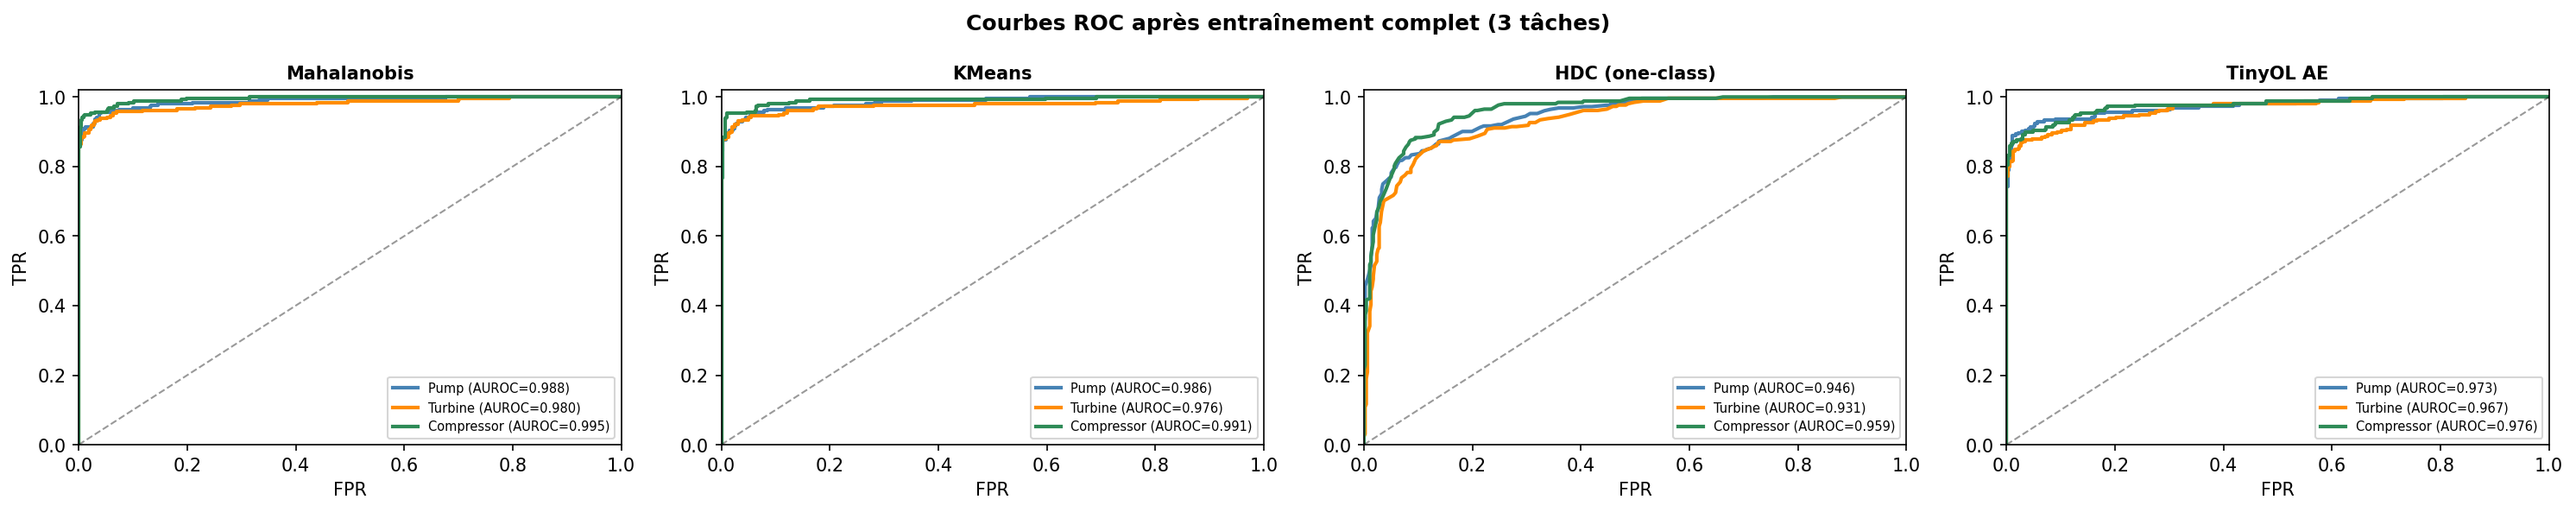

In [10]:
# Section 7 — Courbes ROC par tâche pour chaque modèle (après entraînement complet)
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, name, scores_dict in zip(axes, model_names, all_scores):
    for task_idx, (task_name, color) in enumerate(zip(TASK_NAMES, ["steelblue", "darkorange", "seagreen"])):
        key = (2, task_idx)  # après entraînement sur toutes les tâches
        if key not in scores_dict:
            continue
        y_true, scores = scores_dict[key]
        fpr, tpr, _ = roc_curve(y_true, scores)
        m = compute_anomaly_metrics(y_true, scores)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{task_name} (AUROC={m['auroc']:.3f})")
    ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.4)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

fig.suptitle("Courbes ROC après entraînement complet (3 tâches)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_figure(fig, FIGURES_DIR / "roc_curves_all_tasks.png")
display(Image(str(FIGURES_DIR / "roc_curves_all_tasks.png")))

Modèle                 Params     RAM FP32  % budget 64Ko
------------------------------------------------------------
Mahalanobis                20         80 B           0.12%
KMeans                     28        112 B           0.17%
HDC (one-class)          1024      14344 B          21.89%
TinyOL AE                 102        408 B           0.62%
[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/anomaly_detection/monitoring/ram_comparison.png


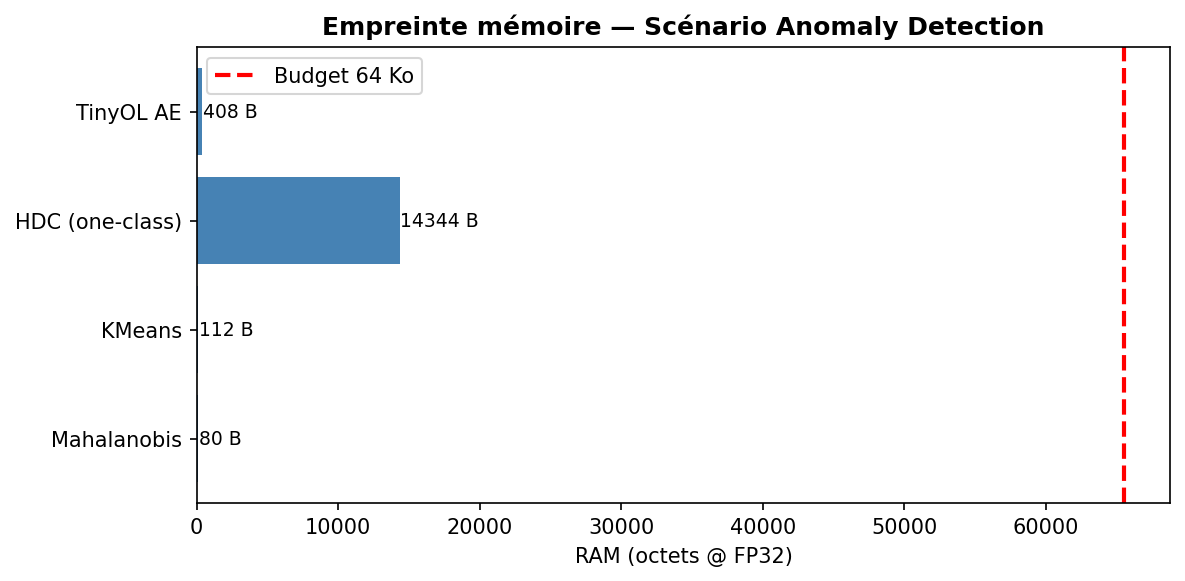

In [11]:
# Section 8 — Comparaison RAM (empreinte mémoire MCU)
# KMeansDetector n'expose pas estimate_ram_bytes() — on estime depuis count_parameters()
def _ram_bytes(model) -> int:
    if hasattr(model, "estimate_ram_bytes"):
        return model.estimate_ram_bytes("fp32")
    elif hasattr(model, "_estimate_ram_bytes"):
        return model._estimate_ram_bytes()
    return model.count_parameters() * 4  # fallback : n_params × 4 B @ FP32

ram_data = {
    "Mahalanobis": _ram_bytes(model_maha),
    "KMeans":      _ram_bytes(model_km),
    "HDC (one-class)": _ram_bytes(model_hdc),
    "TinyOL AE":   _ram_bytes(model_tinyol),
}
params_data = {
    "Mahalanobis": model_maha.count_parameters(),
    "KMeans":      model_km.count_parameters(),
    "HDC (one-class)": model_hdc.count_parameters(),
    "TinyOL AE":   model_tinyol.count_parameters(),
}

print(f"{'Modèle':<20} {'Params':>8} {'RAM FP32':>12} {'% budget 64Ko':>14}")
print("-" * 60)
for name in model_names:
    ram = ram_data[name]
    pct = ram / 65536 * 100
    print(f"{name:<20} {params_data[name]:>8} {ram:>10} B   {pct:>12.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(ram_data.keys()), list(ram_data.values()), color="steelblue")
ax.axvline(65536, color="red", linestyle="--", lw=2, label="Budget 64 Ko")
ax.set_xlabel("RAM (octets @ FP32)")
ax.set_title("Empreinte mémoire — Scénario Anomaly Detection", fontweight="bold")
ax.legend()
for bar, (name, v) in zip(bars, ram_data.items()):
    ax.text(v + 50, bar.get_y() + bar.get_height()/2, f"{v} B", va="center", fontsize=9)
plt.tight_layout()
save_figure(fig, FIGURES_DIR / "ram_comparison.png")
display(Image(str(FIGURES_DIR / "ram_comparison.png")))

## Section 9 — Analyse de la complexité calculatoire (MACs)

| Métrique | Définition |
|----------|------------|
| **MACs inférence** | MACs par sample (modèle final après Task 3) |
| **MACs entraînement** | Coût total sur les 3 tâches CL |
| **Pareto** | Coût total (train + inférence test set) vs avg_AUROC |

> Formules analytiques dans `src/evaluation/compute_cost.py`. Valeurs issues des configs YAML.

In [12]:
# Section 9a — Calcul des MACs (inférence + entraînement)
from src.evaluation.compute_cost import compute_macs, compute_training_macs

# Paramètres depuis les configs déjà chargées (cells 3-6)
n_features: int = cfg_hdc["data"]["n_features"]          # 4
dim_hv: int     = cfg_hdc["hdc"]["D"]                    # 1024
encoder_dims    = cfg_tinyol["backbone"]["encoder_dims"]  # [4,4,2]
decoder_dims    = cfg_tinyol["backbone"]["decoder_dims"]  # [4,4,4]
n_epochs: int   = cfg_tinyol["pretrain"]["epochs"]        # 50
batch_size: int = cfg_tinyol["pretrain"]["batch_size"]    # 64
k_min: int      = cfg_km["k_min"]                         # 2
k_max: int      = cfg_km["k_max"]                         # 8
k_fixed: int    = cfg_km["k_fixed"]                       # 3
n_init: int     = cfg_km["n_init"]                        # 10
max_iter: int   = cfg_km["max_iter"]                      # 300

n_train_per_task = [t["n_train"] for t in tasks]
n_test_per_task  = [t["n_test"]  for t in tasks]
total_test       = sum(n_test_per_task)

# MACs inférence par sample (modèle final = après Task 3)
infer_macs = {
    "HDC":         compute_macs("HDC", n_features=n_features, dim_hv=dim_hv, n_classes=1),
    "TinyOL AE":   compute_macs("TinyOL_AE", n_features=n_features,
                                encoder_dims=encoder_dims, decoder_dims=decoder_dims),
    "KMeans":      compute_macs("KMeans", n_features=n_features, n_clusters=k_fixed),
    "Mahalanobis": compute_macs("Mahalanobis", n_features=n_features),
}

# MACs entraînement par tâche
def _train_macs_task(name: str, n: int) -> int:
    if name == "HDC":
        return compute_training_macs("HDC", n_features=n_features, dim_hv=dim_hv, n_samples=n)
    elif name == "TinyOL AE":
        return compute_training_macs("TinyOL_AE", n_features=n_features, encoder_dims=encoder_dims,
                                     decoder_dims=decoder_dims, n_samples=n,
                                     n_epochs=n_epochs, batch_size=batch_size)
    elif name == "KMeans":
        return compute_training_macs("KMeans", n_features=n_features, n_clusters=k_fixed,
                                     n_samples=n, k_min=k_min, k_max=k_max,
                                     n_init=n_init, max_iter=max_iter)
    else:  # Mahalanobis
        return compute_training_macs("Mahalanobis", n_features=n_features, n_samples=n)

_COMPUTE_NAMES = ["Mahalanobis", "KMeans", "HDC", "TinyOL AE"]
train_macs_per_task = {n: [_train_macs_task(n, s) for s in n_train_per_task] for n in _COMPUTE_NAMES}
train_macs_total    = {n: sum(train_macs_per_task[n]) for n in _COMPUTE_NAMES}

avg_auroc_macs = {
    "Mahalanobis": cl_maha["avg_auroc"],
    "KMeans":      cl_km["avg_auroc"],
    "HDC":         cl_hdc["avg_auroc"],
    "TinyOL AE":   cl_tinyol["avg_auroc"],
}

# Unit checks
assert infer_macs["TinyOL AE"]   == 84,   f"TinyOL AE: {infer_macs['TinyOL AE']}"
assert infer_macs["Mahalanobis"] == 20,   f"Mahalanobis: {infer_macs['Mahalanobis']}"
assert infer_macs["HDC"]         == 5120, f"HDC: {infer_macs['HDC']}"

print(f"{'Modèle':<20} {'Inférence (MACs/sample)':>24} {'Entraînement total (MACs)':>28}")
print("-" * 74)
for name in _COMPUTE_NAMES:
    print(f"{name:<20} {infer_macs[name]:>24,} {train_macs_total[name]:>28,}")

Modèle                Inférence (MACs/sample)    Entraînement total (MACs)
--------------------------------------------------------------------------
Mahalanobis                                20                      110,632
KMeans                                     12                2,802,639,512
HDC                                     5,120                   28,272,640
TinyOL AE                                  84                   69,577,200


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/anomaly_detection/monitoring/complexity_analysis.png


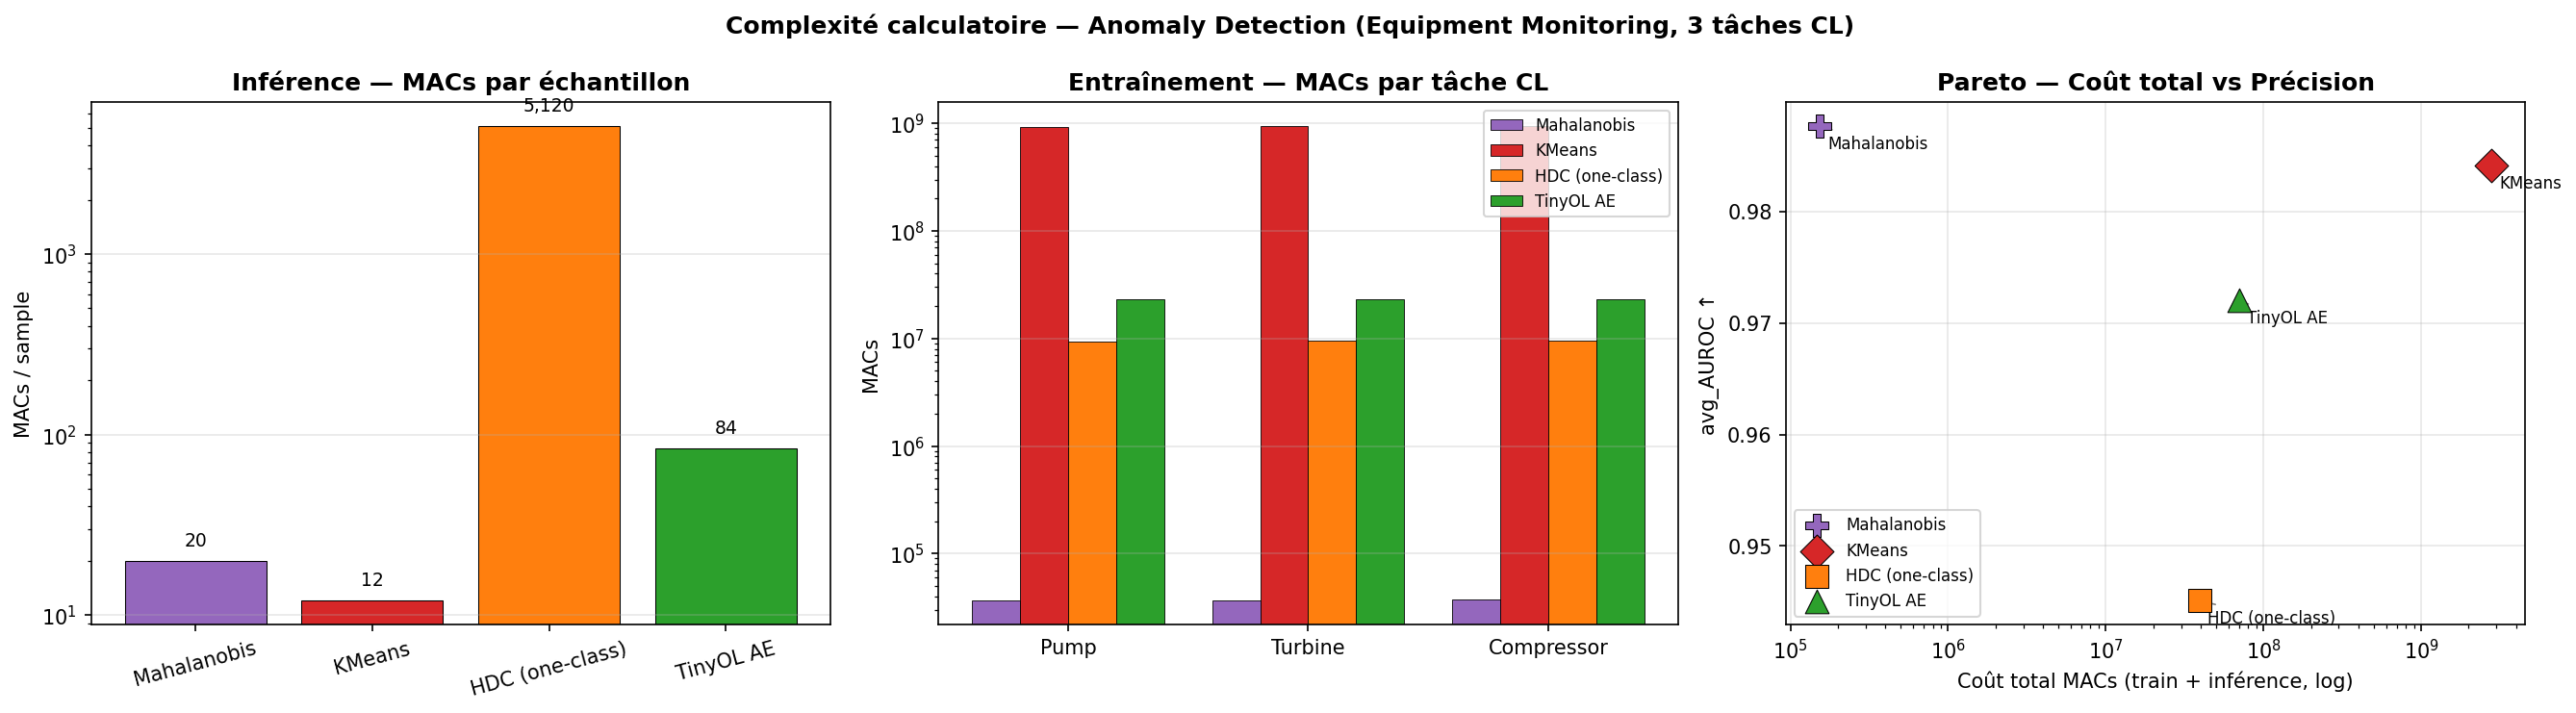

In [13]:
# Section 9b — Plots : inférence MACs / entraînement par tâche / Pareto frontier

_COLORS  = {"Mahalanobis": "#9467bd", "KMeans": "#d62728", "HDC": "#ff7f0e", "TinyOL AE": "#2ca02c"}
_MARKERS = {"Mahalanobis": "P",        "KMeans": "D",         "HDC": "s",        "TinyOL AE": "^"}
_DISPLAY = {
    "Mahalanobis": "Mahalanobis", "KMeans": "KMeans",
    "HDC": "HDC (one-class)", "TinyOL AE": "TinyOL AE",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Inférence MACs par sample
ax1 = axes[0]
display_names = [_DISPLAY[n] for n in _COMPUTE_NAMES]
vals1 = [infer_macs[n] for n in _COMPUTE_NAMES]
bars1 = ax1.bar(display_names, vals1,
                color=[_COLORS[n] for n in _COMPUTE_NAMES],
                edgecolor="black", linewidth=0.5)
for bar, v in zip(bars1, vals1):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
             f"{v:,}", ha="center", va="bottom", fontsize=9)
ax1.set_ylabel("MACs / sample")
ax1.set_title("Inférence — MACs par échantillon", fontweight="bold")
ax1.set_yscale("log")
ax1.tick_params(axis="x", rotation=15)
ax1.grid(axis="y", alpha=0.3)

# Plot 2 — Entraînement MACs par tâche CL (grouped bar)
ax2 = axes[1]
x_pos = np.arange(len(TASK_NAMES))
bar_width = 0.2
for idx, name in enumerate(_COMPUTE_NAMES):
    offsets = x_pos + (idx - 1.5) * bar_width
    ax2.bar(offsets, train_macs_per_task[name],
            width=bar_width, label=_DISPLAY[name],
            color=_COLORS[name], edgecolor="black", linewidth=0.4)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(TASK_NAMES)
ax2.set_ylabel("MACs")
ax2.set_yscale("log")
ax2.set_title("Entraînement — MACs par tâche CL", fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

# Plot 3 — Pareto : coût total vs avg_AUROC
ax3 = axes[2]
cost_auroc = [
    (train_macs_total[n] + infer_macs[n] * total_test, avg_auroc_macs[n], n)
    for n in _COMPUTE_NAMES
]
for total_cost, auroc_val, name in cost_auroc:
    ax3.scatter(total_cost, auroc_val,
                marker=_MARKERS[name], color=_COLORS[name],
                s=140, zorder=5, edgecolor="black", linewidth=0.5,
                label=_DISPLAY[name])
    ax3.annotate(
        _DISPLAY[name],
        xy=(total_cost, auroc_val),
        xytext=(total_cost * 1.12, auroc_val - 0.002),
        fontsize=8,
        arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.8},
    )

# Pareto frontier : points non-dominés triés par coût croissant
_sorted = sorted(cost_auroc, key=lambda x: x[0])
pareto_x, pareto_y, best = [], [], -1.0
for cost, auroc_val, _ in _sorted:
    if auroc_val >= best:
        pareto_x.append(cost)
        pareto_y.append(auroc_val)
        best = auroc_val
if len(pareto_x) > 1:
    ax3.plot(pareto_x, pareto_y, "k--", lw=1.2, alpha=0.6, label="Pareto frontier")

ax3.set_xscale("log")
ax3.set_xlabel("Coût total MACs (train + inférence, log)", fontsize=10)
ax3.set_ylabel("avg_AUROC ↑", fontsize=10)
ax3.set_title("Pareto — Coût total vs Précision", fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

fig.suptitle(
    "Complexité calculatoire — Anomaly Detection (Equipment Monitoring, 3 tâches CL)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
save_figure(fig, FIGURES_DIR / "complexity_analysis.png")
display(Image(str(FIGURES_DIR / "complexity_analysis.png")))

In [14]:
# Section 10 — Sauvegarde des résultats
for name, cl_metrics, auroc_mat, exp_id in [
    ("mahalanobis", cl_maha,   auroc_maha,   "exp_089"),
    ("kmeans",      cl_km,     auroc_km,     "exp_088"),
    ("hdc",         cl_hdc,    auroc_hdc,    "exp_086"),
    ("tinyol_ae",   cl_tinyol, auroc_tinyol, "exp_087"),
]:
    out_dir = REPO_ROOT / f"experiments/{exp_id}_{name}_monitoring_anomaly_detection/results"
    out_dir.mkdir(parents=True, exist_ok=True)
    
    save_anomaly_metrics(
        cl_metrics,
        out_dir / f"cl_anomaly_metrics_{name}.json",
        extra_info={"model": name, "exp_id": exp_id, "scenario": "anomaly_detection"},
    )
    np.save(out_dir / f"auroc_matrix_{name}.npy", auroc_mat)
    print(f"  Sauvegardé : {out_dir}")

print("\nTous les résultats sauvegardés.")

  Sauvegardé : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_089_mahalanobis_monitoring_anomaly_detection/results
  Sauvegardé : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_088_kmeans_monitoring_anomaly_detection/results
  Sauvegardé : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_086_hdc_monitoring_anomaly_detection/results
  Sauvegardé : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_087_tinyol_ae_monitoring_anomaly_detection/results

Tous les résultats sauvegardés.
